In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Enable LaTeX text rendering globally
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\boldmath\bfseries' # or other packages that support bold

# Set the font family (e.g., to serif fonts often used with LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman'] # Or other serif fonts

plt.rcParams.update({'font.size': 13}) # Default font size for most text
from main import get_buyer_best_response
from cost_models import get_price_vector
from ftl import get_costs, get_regrets
from tqdm import tqdm
from plots import plot_demand_bayesian, extra_gradient_equilibrium_bayesian, plot_demand_bayesian_last_iterate

In [2]:
# get players' private types
def get_player_types(Vs_set, game_types):   
    Vs_mappings = []
    player_type_mappings = []  # Maps game_idx to type index for each player
    
    for i in range(n):
        context_mapping_i = {}
        seen_tuples = {}  # Maps tuple to type index
                
        for idx, Vs in enumerate(Vs_set):
            # Create tuple of what player i can observe
            observable_tuple = Vs[i] # player i only observes their constraint V
                    
            if observable_tuple in seen_tuples:
                # Reuse existing type
                type_idx = seen_tuples[observable_tuple]
                context_mapping_i[tuple(Vs)] = type_idx
            else:
                 # Create new type
                type_idx = len(seen_tuples)
                seen_tuples[observable_tuple] = type_idx
                context_mapping_i[tuple(Vs)] = type_idx
                
        Vs_mappings.append(context_mapping_i)
    
    for i in range(n):
        type_mapping_i = {}
        for game_idx, game in enumerate(game_types):
            type_mapping_i[game_idx] = Vs_mappings[i][tuple(game['Vs'])]
        player_type_mappings.append(type_mapping_i)
    
    return player_type_mappings

# initialize step size sequence
def get_step_sizes(num_iter, random=True):
    if random:
        # set step sizes according to AdaOGD
        z0 = 1 / np.log(num_iter + 10)
        Mmax = 0
        step_sizes = []
        for r in range(num_iter): 
            M = np.random.geometric(p=z0)    
            Mmax = max(Mmax, M)               
            eta = (r+1) / np.sqrt((1 + Mmax)) 
            step_sizes.append(eta)
        return [step_size * 1 for step_size in step_sizes]
    else:
        # set deterministic step size schedule from Andrew
        return [(r+2) / np.log(r+2) for r in range(num_iter)]
        # set normal ogd step size schedule
        # return [np.sqrt(r+1) for r in range(num_iter)]

# compute gradient
def gradient_func(player_idx, current_actions, Vs_set, game_types, game_idx):
    # print("computing gradient for player ", player_idx, " ============")
    n = game_types[game_idx]['n']
    T = game_types[game_idx]['T']
    alpha = game_types[game_idx]['alpha']
    beta = game_types[game_idx]['beta']
    S = game_types[game_idx]['supply']
    rs = game_types[game_idx]['reserve']
    p0 = game_types[game_idx]['p_0']
    # K = len(game_types)
    player_types = set(get_player_types(Vs_set, game_types)[player_idx].values())
    k = len(player_types)

    realized_actions = []
    for i in range(n):
        realized_actions.append(current_actions[i][get_player_types(Vs_set, game_types)[i][game_idx]])
    # print("realized_actions: ", realized_actions)

    i = player_idx
    type_idx = get_player_types(Vs_set, game_types)[i][game_idx]  

    # get aggregate actions of other players
    realized_actions_opp = sum(realized_actions[j] for j in range(n) if j != i)

    # get gradient wrt realized action
    realized_gradient = alpha * np.matmul(np.eye(T) + np.ones((T, T)), realized_actions[i]) \
                + alpha * np.matmul(np.tril(np.ones((T, T))), realized_actions_opp - S) \
                    + beta * (2 * realized_actions[i] + realized_actions_opp - S)
    if rs is not None:
        realized_gradient -= rs[i] * np.ones(T)
    realized_gradient += p0 * np.ones(T)
    
    gradient_matrix = np.zeros((k, T))
    gradient_matrix[type_idx] = realized_gradient
    #print("gradient_matrix: ", gradient_matrix)
    
    return gradient_matrix

# project action onto feasible region
def projection_func(action, Vs_set, game_types, player_idx):
    "Implements constraint -V <= sum(action) <= V"
    T = game_types[0]['T']
    Vs_i = np.unique(np.array(Vs_set).transpose()[player_idx])

    offset_minus = np.maximum(np.sum(action, axis=1) - Vs_i, 0) / T
    offset_plus = np.maximum(-1*Vs_i - np.sum(action, axis=1), 0) / T
    
    projected_action = np.zeros((len(Vs_i), T))
    for k, Vs in enumerate(Vs_i):
        projected_action[k] = action[k] - offset_minus[k] + offset_plus[k]
    return projected_action

# simulate learning dynamics
def no_regret_dynamics(Vs_set, game_types, game_sequence, num_iter, gradient_func, get_step_sizes, random=True, projection_func=None):
    n = game_types[0]['n']
    T = game_types[0]['T']

    # initialize step size sequence for each player
    step_size_seqs = []
    for i in range(n):
        step_size_seqs.append(get_step_sizes(num_iter, random))

    actions = [[] for _ in range(n)]
    current_actions = []

    # initialize actions at round 1
    game_idx = game_sequence[0]
    for i in range(n):
        player_types = set(get_player_types(Vs_set, game_types)[i].values())
        k = len(player_types)
        action = np.zeros((k, T))
        for type_idx in player_types:
            # initalize row for each observable type
            V_upper = game_types[game_idx]['Vs'][i]
            action[type_idx] = np.ones(T) * (V_upper / T)  
        actions[i].append(action)
        current_actions.append(action) 
    
    # run no-regret dynamics
    for r in tqdm(range(1, num_iter), desc="No-regret dynamics"):
        # get realized game type
        game_idx = game_sequence[r]
        game_type = game_types[game_idx]
        Vs = game_type['Vs']

        grads = [gradient_func(i, current_actions, Vs_set, game_types, game_idx) for i in range(n)]
        for i in range(n):
            # update action
            eta = step_size_seqs[i][r-1]
            new_action = current_actions[i] - (1/eta) * grads[i]
            current_actions[i] = projection_func(new_action, Vs_set, game_types, i) if projection_func else new_action
            # store action
            actions[i].append(current_actions[i])
    
    return actions

In [4]:
# initialize game types
n = 2
T = 100
p0 = 0

# number of iterations of learning
num_iter = 500

# construct game sequence
Vs_set = [[10, 20], [10, 25], [10, 30], [15, 20], [15, 25], [15, 30], [20, 20], [20, 25], [20, 30]]
# Vs_set = [[10, 20]]
game_types = []
game_sequence = []
np.random.seed(0)
for r in range(num_iter):
    # sample Vs uniformly at random
    Vs = Vs_set[np.random.choice(len(Vs_set))]
    # sample supply vector from gaussian centered at 0
    S = np.random.normal(0, 1, T)
    # S = np.zeros(T)
    # sample reserves from uniform distribution
    # rs = [np.random.uniform(0, 100) for _ in range(n)]
    # rs = [1000, 1000]
    r1 = np.random.normal(Vs[0]/3, 1)
    r2 = np.random.normal(Vs[1]/3, 1)
    rs = [r1, r2] 
    # alpha, beta = 1, 1
    beta = 0.5*(Vs[0] + Vs[1])/20
    alpha = 0.1
    
    game_types.append({"n": n, "T": T, "p_0": p0, "Vs": Vs, "alpha": alpha, "beta": beta, "supply": S, "reserve": rs, "exp": 1})
    game_sequence.append(r)
type_mappings = get_player_types(Vs_set, game_types)
type_indices = [set(type_mappings[0].values()), set(type_mappings[1].values())]
print("player type indices: ", type_indices)

random_step_sizes = True # if True, implements step size sequence of AdaOGD

N = 1 # number of runs
last_iterate_actions_N = []
for _ in range(N):
    actions = no_regret_dynamics(Vs_set, game_types, game_sequence, num_iter, gradient_func, get_step_sizes, random_step_sizes, projection_func)
    last_iterate_actions = [actions[i][-1] for i in range(n)]
    # print("last iterate actions: ", last_iterate_actions)
    last_iterate_actions_N.append(last_iterate_actions)

# calculate average of last iterate actions across all N runs
avg_last_iterate = np.mean([last_iterate_actions_N[run] for run in range(N)], axis=0)
# print("\nAverage last iterate actions:")
# print(avg_last_iterate)

No-regret dynamics:   2%|▏         | 11/499 [00:00<00:05, 87.89it/s]

player type indices:  [{0, 1, 2}, {0, 1, 2}]


No-regret dynamics: 100%|██████████| 499/499 [00:01<00:00, 301.06it/s]


In [5]:
# initialize Bayesian game instance and compute BNE
n, k, T = 2, 3, 100
supply = [0 for i in range(T)]
bayesian_game_dict = {
        "n" : n,
        "T" : T,
        "k" : k,
        "p_0" : 0,
        "supply" : supply
    }

# Vs and reserves are an n (agent) x k (type) matrix. 
Vs = np.array([
        [10, 15, 20],
        [20, 25, 30]
    ])
reserves = Vs/3
bayesian_game_dict["Vs"] = Vs
bayesian_game_dict["reserves"] = reserves

# key is agent1 type, agent2 type
# All that really matters is the expected value of alpha, beta conditioned on the type. Which is what this is
alphas, betas, type_dist = np.zeros((k,k)), np.zeros((k,k)), np.zeros((k,k))
for l0 in range(k):
    for l1 in range(k):
        key = (l0, l1)
        beta = 0.5*(bayesian_game_dict["Vs"][(0,l0)] + bayesian_game_dict["Vs"][(1,l1)])/20
        alpha = 0.1
        alphas[l0, l1] = alpha
        betas[l0, l1] = beta
        type_dist[l0, l1] = 1/k**2

bayesian_game_dict["alphas"] = alphas
bayesian_game_dict["betas"] = betas
bayesian_game_dict["type_dist"] = type_dist

BNE = extra_gradient_equilibrium_bayesian(bayesian_game_dict)

Text(0.5, 1.0, '\\textbf{Comparison of Last Iterate \\& BNE Strategies}')

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


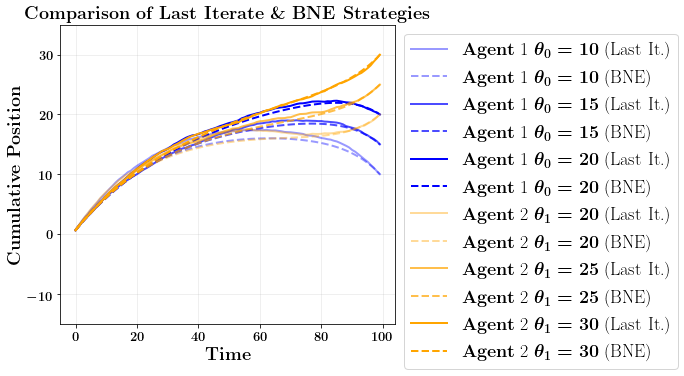

In [6]:
# plot last iterate vs BNE strategies
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
plot_demand_bayesian_last_iterate(ax, bayesian_game_dict, np.array(avg_last_iterate), BNE, supply, 'cumulative', plot_y_label=True)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=18)
ax.set_title(r'\textbf{Comparison of Last Iterate \& BNE Strategies}', fontsize=18)
# plt.savefig('last_iterate_vs_BNE.png', bbox_inches='tight')

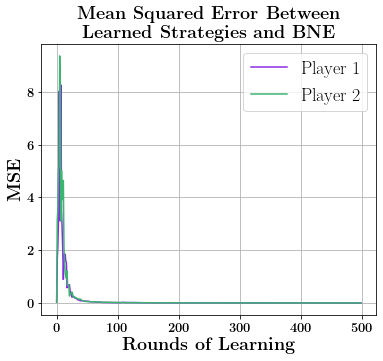

In [7]:
# compute MSE between BNE strategies and sequence of learned strategies
def compute_mses(BNE, actions):
    num_iter = len(actions[0])
    mses = [[] for _ in range(n)]
    for i in range(n):
        for r in range(num_iter):
            mses[i].append(np.mean((BNE[i] - actions[i][r])**2))
    return mses

mses = compute_mses(BNE, actions)

# plot MSEs over time for both players
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(mses[0], label='Player 1', color='blueviolet')
ax.plot(mses[1], label='Player 2', color='mediumseagreen')
ax.set_xlabel(r'\textbf{Rounds of Learning}', fontsize=18)
ax.set_ylabel(r'\textbf{MSE}', fontsize=18)
ax.set_title(r'\textbf{Mean Squared Error Between}' '\n' r'\textbf{Learned Strategies and BNE}', fontsize=18)
ax.legend(fontsize=18)
ax.grid(True)
# plt.xlim(450, len(mses[0]))
# plt.ylim(0, 0.0005)
# plt.savefig('MSE.png', bbox_inches='tight')
plt.show()